## Imports

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from utils import dataloader, connect_gt_and_pred, calculate_error_distributions

from statsforecast import StatsForecast
from neuralforecast import NeuralForecast
from neuralforecast.losses.numpy import mae, mse, rmse

c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\statsforecast\core.py:26: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Load model and environment

In [3]:
config = {
        'normalize': True,
        'horizon': 3,
        'snippet_length': 24,
        'train_dataset': 'ICU_train',
        'test_dataset': 'ICU_test_10',
}

horizon = config['horizon']
snippet_length = config['snippet_length']

In [4]:
model_path = "models/2025_06_04_17_34" # TimesNet 20k steps
# model_path = "models/2025_06_04_23_33" # iTransformer 20k steps

In [5]:
nf = NeuralForecast.load(path=model_path)

print("validing date and time: ", model_path[7:])
print("valided model(s): ", nf.models)


Seed set to 1


validing date and time:  2025_06_04_17_34
valided model(s):  [TimesNet]


## Load and prep test data

In [6]:
print('Loading dataset: ', config['test_dataset'])
data_test = dataloader(config=config, train=False)
Y_df_test = data_test.find_all_continuous_snippets(hours=snippet_length)
print('Done!')

Loading dataset:  ICU_test_10


Done!


In [7]:
# drop last horizon length y values for prediction
ids_to_drop = [i for i in range(len(Y_df_test)) if i % snippet_length >= snippet_length-horizon]
ids_to_drop_for_comparison = [i for i in range(len(Y_df_test)) if i % snippet_length < snippet_length-horizon]
Y_df_gt_window = Y_df_test.drop(ids_to_drop)
Y_df_gt_horizon = Y_df_test.drop(ids_to_drop_for_comparison)

## Run prediction

In [8]:
Y_hat_df_2 = nf.predict(df=Y_df_gt_window).reset_index()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\neuralforecast\core.py:196: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


## Clip and denormalize predictions

In [9]:
for model in nf.models:
    Y_hat_df_2[str(model)] = Y_hat_df_2[str(model)].clip(lower=0.0)

if config['normalize']:

    # denormalize GT values
    Y_df_gt_horizon['y'] = data_test.scaler.inverse_transform(Y_df_gt_horizon['y'].values.reshape(-1,1))
    Y_df_test['y'] = data_test.scaler.inverse_transform(Y_df_test['y'].values.reshape(-1,1))
    
    # denormalize predicted values
    for model in nf.models:
        Y_hat_df_2[str(model)] = data_test.scaler.inverse_transform(Y_hat_df_2[str(model)].values.reshape(-1,1))

## Calculate and plot metrics and results

In [10]:
# calculate metrics
metrics_cols = ['Model Name', 'MAE', 'MSE', 'RMSE']
metrics = pd.DataFrame(columns=metrics_cols)
for model in nf.models:
    model_metrics = {metrics_cols[0]: str(model)}
    model_metrics['MAE'] = mae(Y_hat_df_2[str(model)], Y_df_gt_horizon['y'])
    model_metrics['MSE'] = mse(Y_hat_df_2[str(model)], Y_df_gt_horizon['y'])
    model_metrics['RMSE'] = rmse(Y_hat_df_2[str(model)], Y_df_gt_horizon['y'])

    model_metrics_df = pd.DataFrame(model_metrics, index=[0])
    metrics = pd.concat([metrics, model_metrics_df], ignore_index=True)

In [11]:
df_to_plot_2 = connect_gt_and_pred(df_gt=Y_df_test, df_pred=Y_hat_df_2, snippet_length=snippet_length, horizon=horizon)

Started merging function
Cutoff timestamps appended


  1%|          | 178/23898 [00:00<00:14, 1631.55it/s]

100%|██████████| 23898/23898 [00:13<00:00, 1771.52it/s]


In [12]:
prediction_graphs = StatsForecast.plot(Y_df_test, df_to_plot_2.drop(columns=['y', 'cutoff']), max_insample_length=1260)
histograms, means_stds_df = calculate_error_distributions(Y_df_gt_horizon, Y_hat_df_2, models=nf, horizon=horizon)
plt.close(histograms)

0 0.004131980932540436
1 0.003076467478354971
2 0.002740026081892621




  Model name Statistic           t+1           t+2       t+3
0   TimesNet      Mean  6.026973e-07  6.743008e-07 -0.000005
1   TimesNet       Std  3.937661e-04  3.843103e-04  0.000372


## Visualize

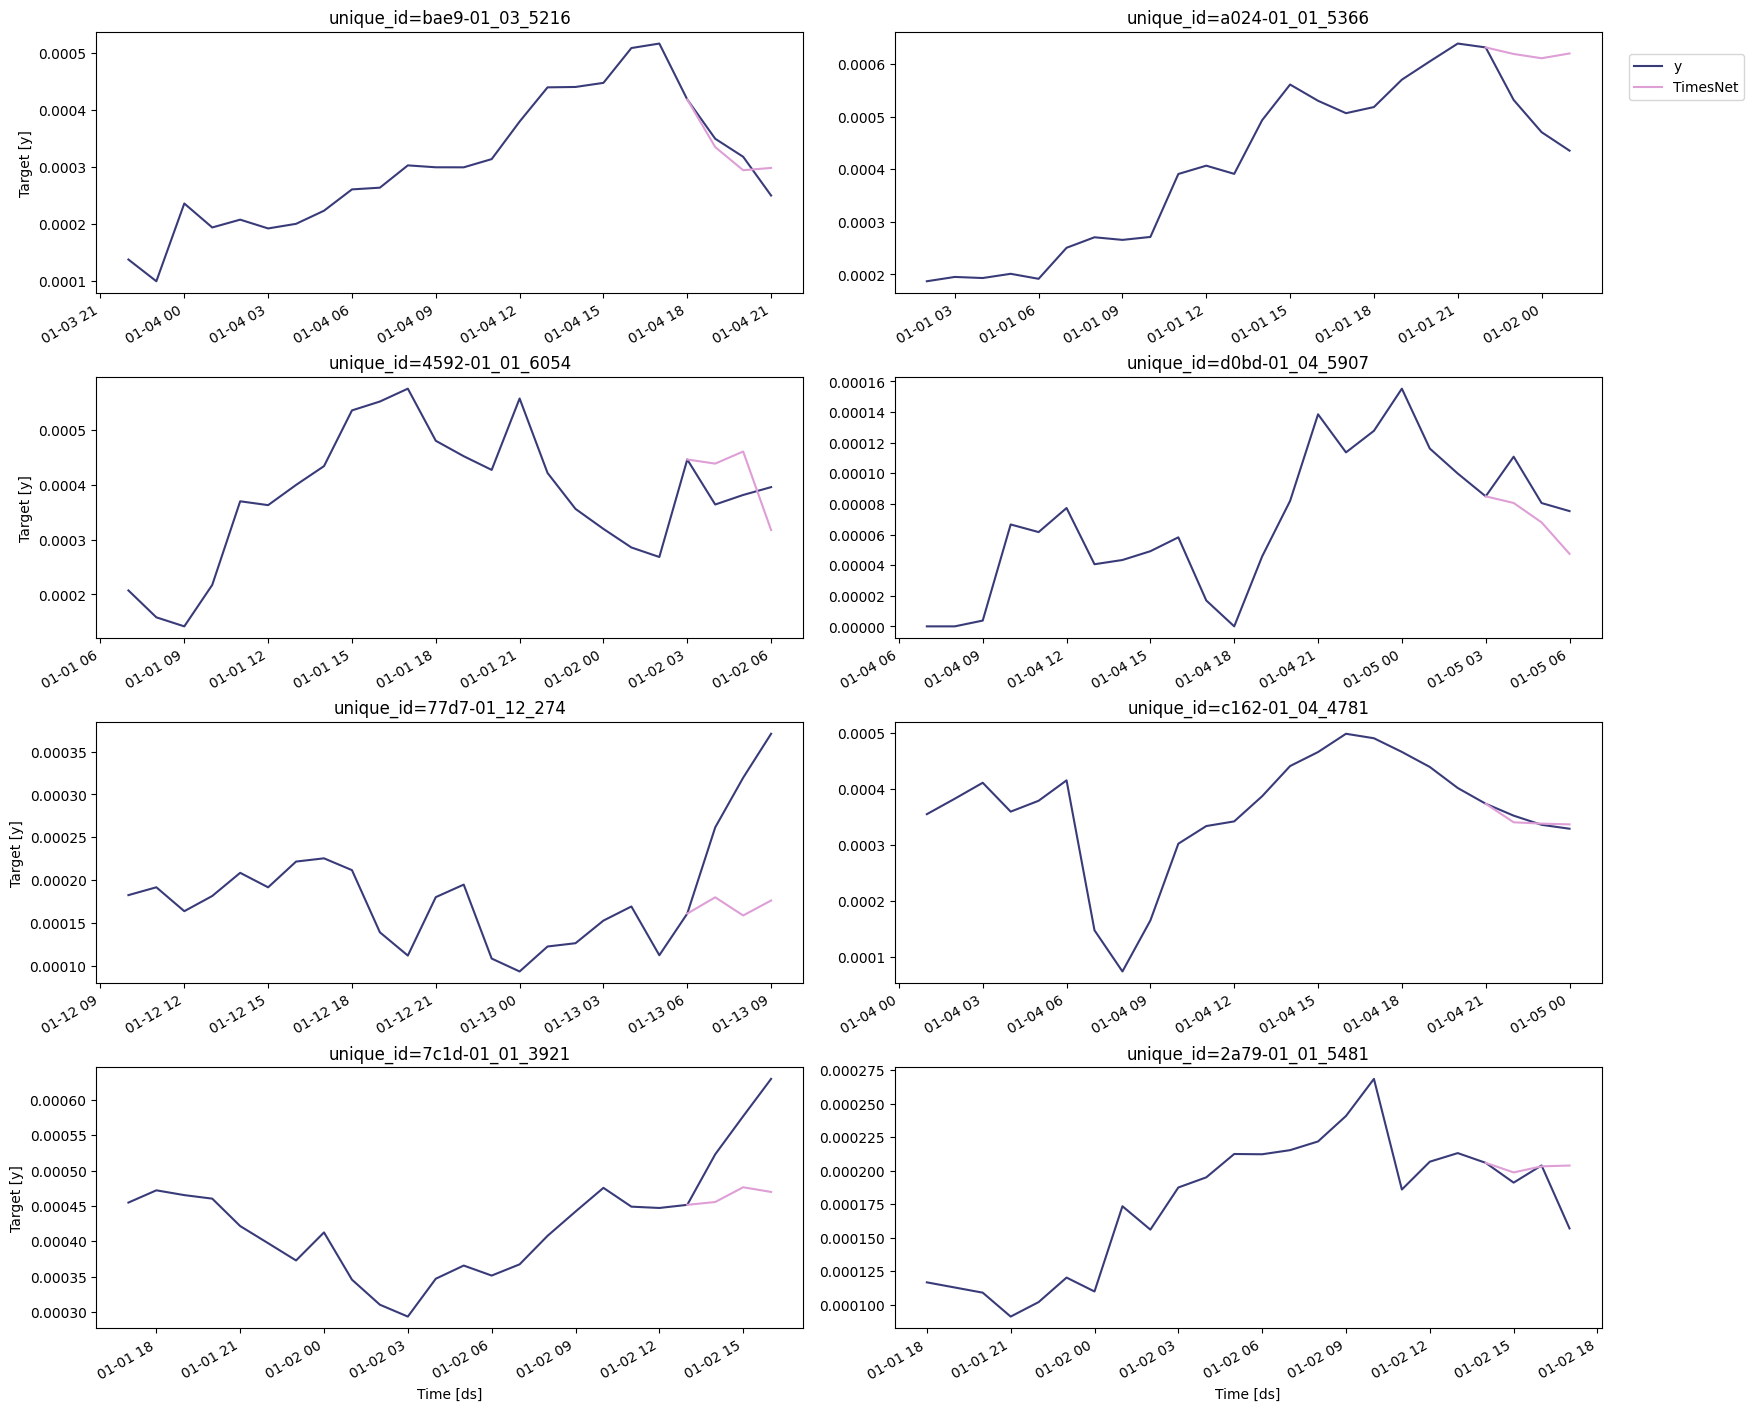

In [13]:
prediction_graphs

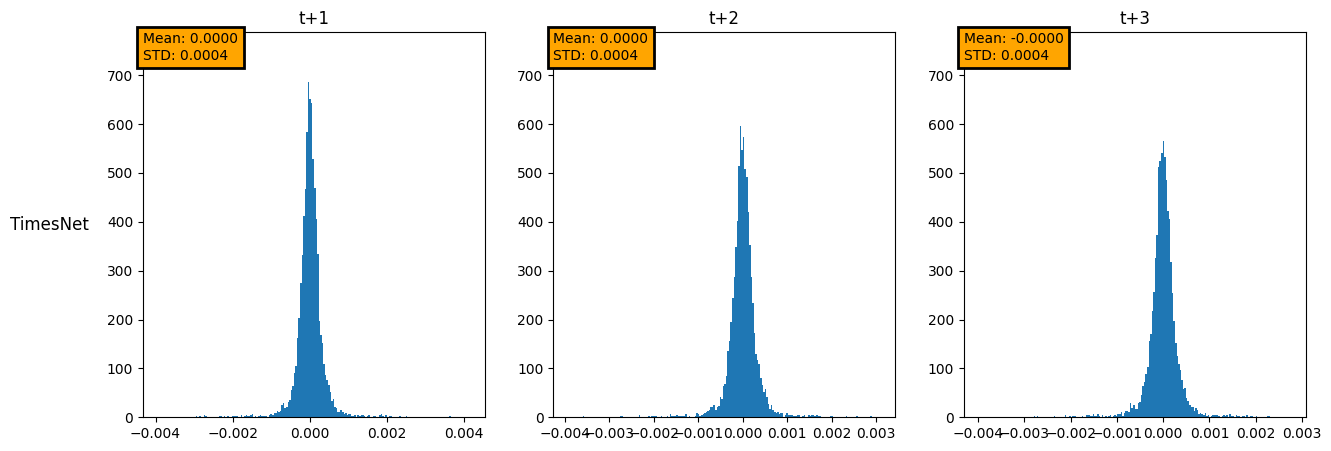

In [14]:
histograms

In [15]:
means_stds_df['t+1'][0]

6.026973368889738e-07

# Bootstrap intervals

## Load and prep validation dataset

In [16]:
print('Loading dataset: ICU_validation dataset')
data_valid = dataloader(config=config, train=False, valid=True)
Y_df_valid = data_valid.find_all_continuous_snippets(hours=snippet_length)
print('Done!')

Loading dataset: ICU_validation dataset


Done!


In [17]:
# drop last horizon length y values for prediction
ids_to_drop = [i for i in range(len(Y_df_valid)) if i % snippet_length >= snippet_length-horizon]
ids_to_drop_for_comparison = [i for i in range(len(Y_df_valid)) if i % snippet_length < snippet_length-horizon]
Y_df_valid_gt_window = Y_df_valid.drop(ids_to_drop)
Y_df_valid_gt_horizon = Y_df_valid.drop(ids_to_drop_for_comparison)

## Predict on validation dataset

In [18]:
Y_hat_df_valid = nf.predict(df=Y_df_valid_gt_window).reset_index()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\neuralforecast\core.py:196: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


## Clip and denormalize predictions

In [19]:
for model in nf.models:
    Y_hat_df_valid[str(model)] = Y_hat_df_valid[str(model)].clip(lower=0.0)

if config['normalize']:

    # denormalize GT values
    Y_df_valid_gt_horizon['y'] = data_valid.scaler.inverse_transform(Y_df_valid_gt_horizon['y'].values.reshape(-1,1))
    Y_df_valid['y'] = data_valid.scaler.inverse_transform(Y_df_valid['y'].values.reshape(-1,1))
    
    # denormalize predicted values
    for model in nf.models:
        Y_hat_df_valid[str(model)] = data_valid.scaler.inverse_transform(Y_hat_df_valid[str(model)].values.reshape(-1,1))

## Calculate residuals

In [20]:
Y_df_valid_gt_horizon_sorted = Y_df_valid_gt_horizon.sort_values(['unique_id', 'ds']).reset_index(drop=True)
Y_hat_df_valid_sorted = Y_hat_df_valid.sort_values(['unique_id', 'ds']).reset_index(drop=True)

residuals = Y_df_valid_gt_horizon_sorted['y'] - Y_hat_df_valid_sorted[str(nf.models[0])]


## Calculate 5th and 95th percentile, and concatenate results

In [21]:
runs = 1000


samples = []
for _ in range(runs):
    sampled = Y_hat_df_2[str(nf.models[0])] + np.random.choice(residuals, size=len(Y_hat_df_2[str(nf.models[0])]), replace=True)
    samples.append(sampled)

samples = np.stack(samples)
lower = np.percentile(samples, 5, axis=0)
lower = np.clip(lower, a_min=1e-7, a_max=None)
upper = np.percentile(samples, 95, axis=0)
median = np.percentile(samples, 50, axis=0)

Y_hat_df_2['95'] = upper
Y_hat_df_2['05'] = lower
Y_hat_df_2['median'] = median

## Prepare and plot results

In [22]:
df_to_plot_2 = connect_gt_and_pred(df_gt=Y_df_test, df_pred=Y_hat_df_2, snippet_length=snippet_length, horizon=horizon)

Started merging function
Cutoff timestamps appended


  1%|          | 181/23898 [00:00<00:14, 1654.70it/s]

100%|██████████| 23898/23898 [00:15<00:00, 1505.34it/s]


In [23]:
prediction_graphs = StatsForecast.plot(Y_df_test, df_to_plot_2.drop(columns=['y', 'cutoff']), max_insample_length=1260)

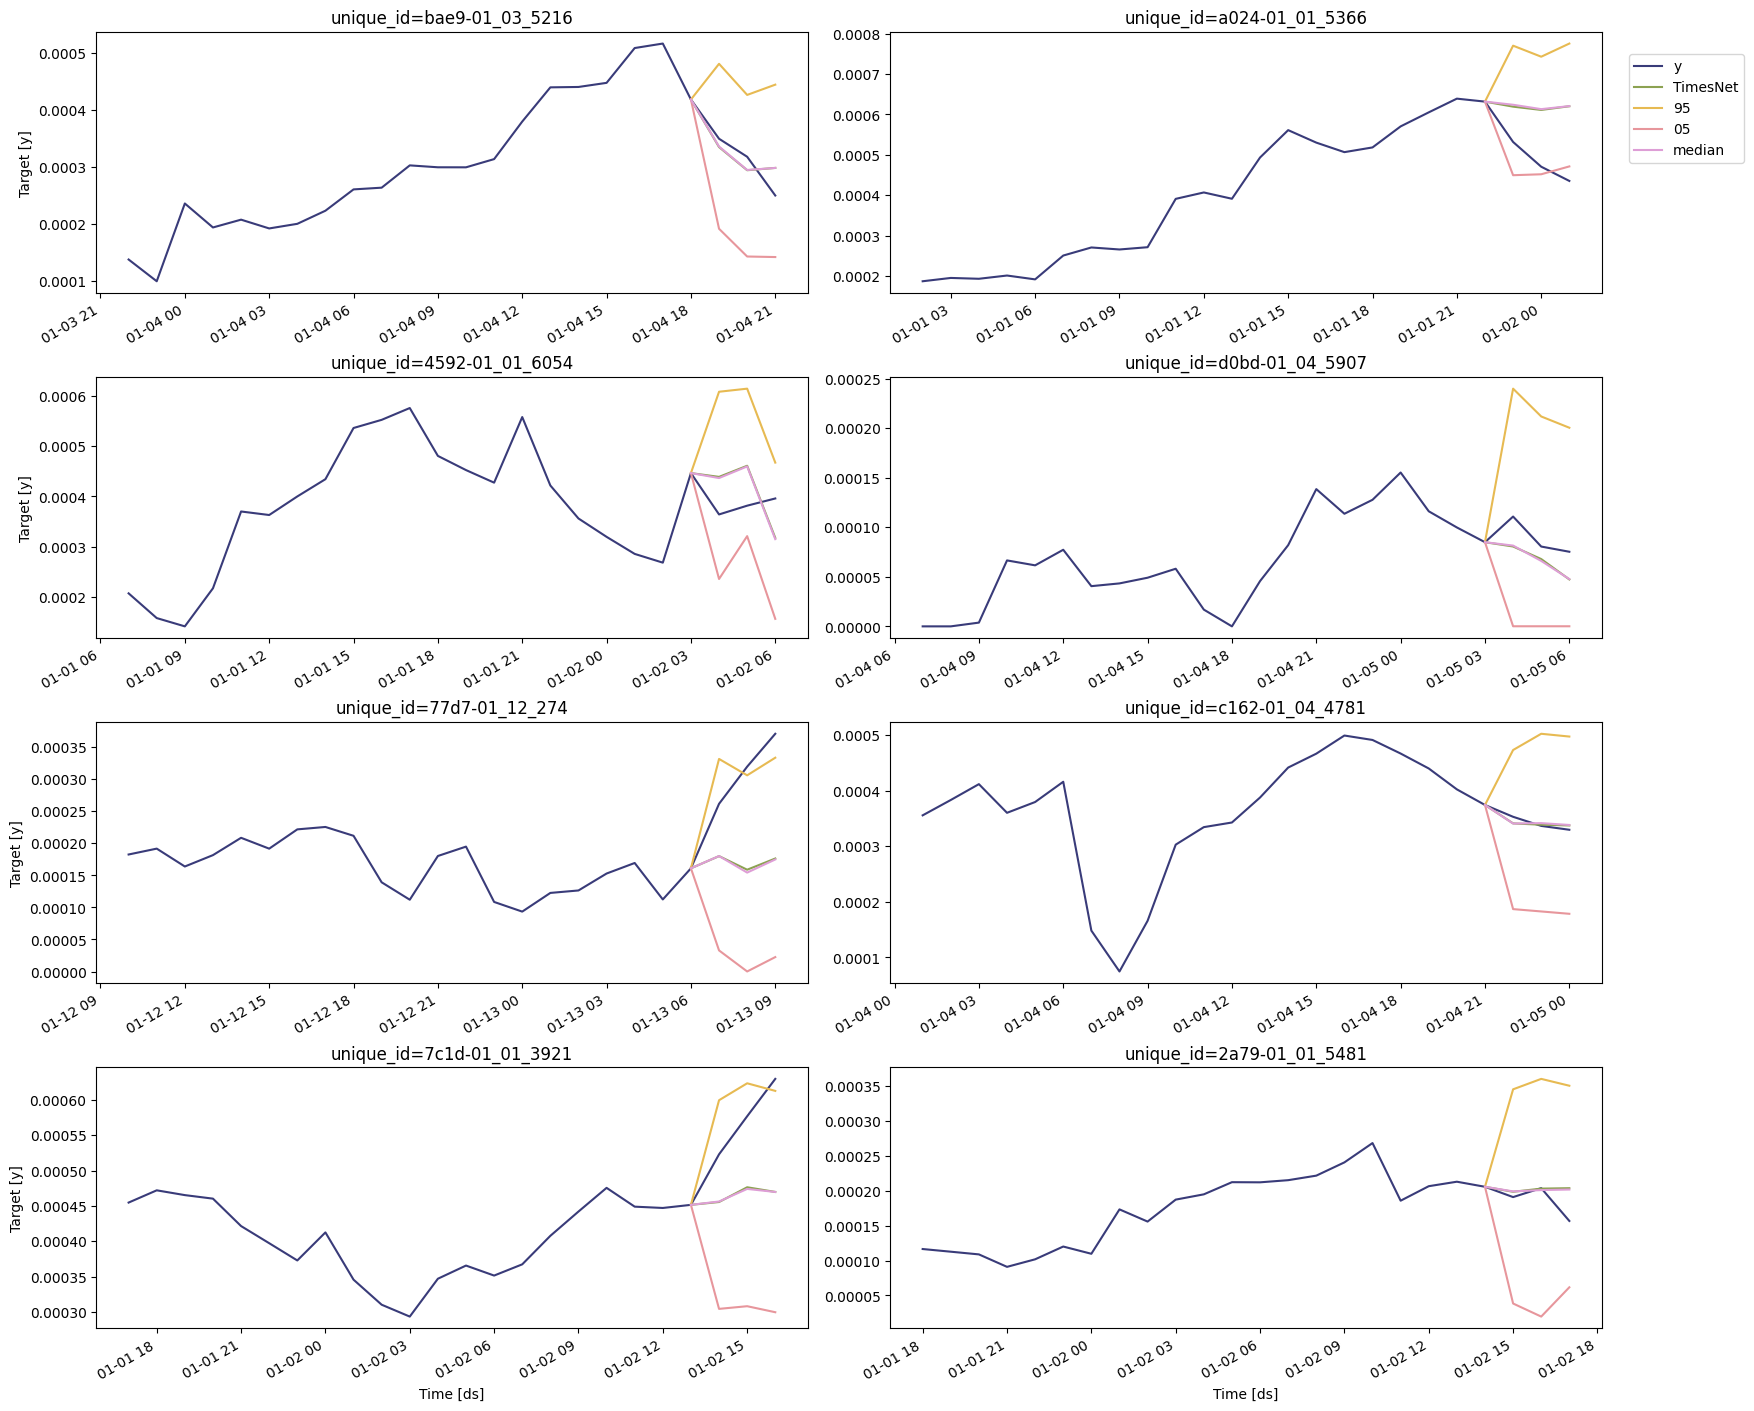

In [24]:
prediction_graphs